# Lead-Time Scenario Policy Engine

The previous notebook converted conformal prediction intervals into safety stock and selected a tuned safety factor of 0.6 based on cost-service sensitivity analysis.

This notebook extends the framework toward lead-time uncertainty. Instead of assuming a fixed replenishment lead time, multiple lead-time scenarios are tested. The goal is to evaluate how inventory cost, stockout risk, fill rate, and recommended safety factor change under normal and delayed replenishment conditions.

This phase is important because real supply chains rarely operate with fixed lead times. Supplier delays, transportation disruptions, and operational uncertainty can increase both stockout risk and inventory cost. Therefore, a business-ready inventory policy should be tested not only under demand uncertainty, but also under lead-time uncertainty.




In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/inventory-optimization-ml-or

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!git config --global user.email "smrititubid@gmail.com"
!git config --global user.name "smrititubid-afk"

Mounted at /content/drive
/content/drive/MyDrive/inventory-optimization-ml-or


In [2]:
df = pd.read_csv("data/processed/conformal_predictions_phase3.csv")

print("Data shape:", df.shape)
df.head()

Data shape: (2940, 34)


,id,item_id,dept_id,cat_id,store_id,state_id,avg_demand,std_demand,cv,zero_demand_ratio,...,lag_1,lag_7,lag_28,rolling_mean_7,rolling_mean_28,rolling_std_7,rolling_std_28,prediction,lower_bound,upper_bound
0,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,0.0,0.0,0.0,0.0,0.035714,0.0,0.188982,0.087015,0.0,1.810284
1,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,0.0,0.0,0.0,0.0,0.035714,0.0,0.188982,0.083071,0.0,1.806339
2,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,0.0,0.0,0.0,0.0,0.035714,0.0,0.188982,0.083071,0.0,1.806339
3,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,0.0,0.0,0.0,0.0,0.035714,0.0,0.188982,0.083071,0.0,1.806339
4,FOODS_1_022_CA_4_validation,FOODS_1_022,FOODS_1,FOODS,CA_4,CA,0.095661,0.398411,4.164373,0.928385,...,0.0,0.0,0.0,0.0,0.035714,0.0,0.188982,0.103592,0.0,1.826860


In [3]:
required_cols = ['sales', 'prediction', 'lower_bound', 'upper_bound']

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

All required columns are present.


Cleaning prediction interval columns

In [4]:
df['prediction'] = df['prediction'].clip(lower=0)
df['lower_bound'] = df['lower_bound'].clip(lower=0)
df['upper_bound'] = df['upper_bound'].clip(lower=0)

df['safety_stock_signal'] = df['upper_bound'] - df['prediction']
df['safety_stock_signal'] = df['safety_stock_signal'].clip(lower=0)

df[['sales', 'prediction', 'lower_bound', 'upper_bound', 'safety_stock_signal']].head()

,sales,prediction,lower_bound,upper_bound,safety_stock_signal
0,0,0.087015,0.0,1.810284,1.723269
1,0,0.083071,0.0,1.806339,1.723269
2,0,0.083071,0.0,1.806339,1.723269
3,0,0.083071,0.0,1.806339,1.723269
4,0,0.103592,0.0,1.826860,1.723269


The prediction, lower bound, and upper bound columns were clipped to avoid negative demand values. This is necessary because demand cannot be negative in an inventory setting. The safety stock signal was then calculated as the difference between the conformal upper bound and the point forecast.

This safety stock signal represents the uncertainty buffer suggested by the conformal prediction interval. A larger gap between the upper bound and the point forecast indicates higher demand uncertainty and therefore a potentially larger inventory buffer.

Defineing business cost assumptions

In [5]:
holding_cost = 1
stockout_cost = 5

print("Holding cost per extra unit:", holding_cost)
print("Stockout penalty per unmet unit:", stockout_cost)

Holding cost per extra unit: 1
Stockout penalty per unmet unit: 5


## Business Cost Assumptions

Two cost components are considered in this notebook.

The first is holding cost, which represents the cost of carrying excess inventory. The second is stockout cost, which represents the penalty associated with unmet demand. In this experiment, the stockout penalty is set higher than the holding cost because stockouts can lead to lost sales, poor customer experience, and service-level failure.

These values are simplified assumptions for experimental comparison. In a real company, they would be replaced by SKU-specific holding costs, margin loss, shortage penalties, and service-level targets.


Demand and Lead-Time Scenario Definition

Three lead-time scenarios were created: normal lead time, moderate delay, and severe delay. These scenarios represent different replenishment conditions that a firm may face in practice. In addition, demand scenarios were created using the conformal prediction interval: lower bound as low demand, point prediction as expected demand, and upper bound as high demand.

This converts the conformal interval into a simple scenario-based decision framework. Instead of relying on a single forecast, the inventory policy is tested under different possible demand and lead-time outcomes.

In [6]:
lead_time_scenarios = pd.DataFrame({
    'lead_time_scenario': ['Normal Lead Time', 'Moderate Delay', 'Severe Delay'],
    'lead_time_days': [7, 10, 14],
    'lead_time_probability': [0.60, 0.30, 0.10]
})

lead_time_scenarios

,lead_time_scenario,lead_time_days,lead_time_probability
0,Normal Lead Time,7,0.6
1,Moderate Delay,10,0.3
2,Severe Delay,14,0.1


The scenario evaluation function calculates expected inventory performance for a given safety factor. For each lead-time scenario and demand scenario, it computes the policy order quantity, holding cost, stockout cost, total cost, stockout units, fill rate, and cycle service level.

This function is the core decision engine of the notebook. It connects forecast uncertainty with inventory outcomes and allows different safety factors to be compared under uncertain replenishment conditions.

In [7]:
demand_scenarios = [
    {
        'demand_scenario': 'Low Demand',
        'column': 'lower_bound',
        'probability': 0.20
    },
    {
        'demand_scenario': 'Expected Demand',
        'column': 'prediction',
        'probability': 0.50
    },
    {
        'demand_scenario': 'High Demand',
        'column': 'upper_bound',
        'probability': 0.30
    }
]

demand_scenarios

[{'demand_scenario': 'Low Demand',
  'column': 'lower_bound',
  'probability': 0.2},
 {'demand_scenario': 'Expected Demand',
  'column': 'prediction',
  'probability': 0.5},
 {'demand_scenario': 'High Demand',
  'column': 'upper_bound',
  'probability': 0.3}]

Conformal interval gives demand uncertainty:
lower_bound, prediction, upper_bound

Lead-time scenarios give supply uncertainty:
7 days, 10 days, 14 days

Together:
Demand uncertainty × Lead-time uncertainty

Scenario-based policy evaluation function

In [8]:
def evaluate_safety_factor_under_scenarios(data, safety_factor):
    total_expected_holding_cost = 0
    total_expected_stockout_cost = 0
    total_expected_cost = 0
    total_expected_stockout_units = 0
    total_expected_demand = 0
    total_expected_stockout_events = 0
    total_weight = 0

    n_rows = len(data)

    for _, lt_row in lead_time_scenarios.iterrows():
        lead_time = lt_row['lead_time_days']
        lead_time_prob = lt_row['lead_time_probability']

        # Policy order quantity under lead-time uncertainty
        # prediction * lead_time = expected demand during replenishment period
        # safety stock grows with sqrt(lead_time), a simple uncertainty scaling assumption
        policy_order = np.ceil(
            data['prediction'] * lead_time
            + safety_factor * data['safety_stock_signal'] * np.sqrt(lead_time)
        )

        for scenario in demand_scenarios:
            demand_col = scenario['column']
            demand_prob = scenario['probability']

            scenario_weight = lead_time_prob * demand_prob

            scenario_demand = data[demand_col] * lead_time

            holding_units = np.maximum(policy_order - scenario_demand, 0)
            stockout_units = np.maximum(scenario_demand - policy_order, 0)

            holding_cost_total = holding_units.sum() * holding_cost
            stockout_cost_total = stockout_units.sum() * stockout_cost
            total_cost = holding_cost_total + stockout_cost_total

            stockout_events = (stockout_units > 0).sum()

            total_expected_holding_cost += scenario_weight * holding_cost_total
            total_expected_stockout_cost += scenario_weight * stockout_cost_total
            total_expected_cost += scenario_weight * total_cost
            total_expected_stockout_units += scenario_weight * stockout_units.sum()
            total_expected_demand += scenario_weight * scenario_demand.sum()
            total_expected_stockout_events += scenario_weight * stockout_events
            total_weight += scenario_weight

    fill_rate = 1 - (total_expected_stockout_units / total_expected_demand)

    cycle_service_level = 1 - (
        total_expected_stockout_events / (n_rows * total_weight)
    )

    return {
        'safety_factor': safety_factor,
        'expected_total_cost': total_expected_cost,
        'expected_holding_cost': total_expected_holding_cost,
        'expected_stockout_cost': total_expected_stockout_cost,
        'expected_stockout_units': total_expected_stockout_units,
        'expected_demand': total_expected_demand,
        'fill_rate': fill_rate,
        'cycle_service_level': cycle_service_level
    }

Runing safety factor simulation

In [9]:
safety_factors = np.arange(0.0, 1.1, 0.1)

scenario_results = []

for factor in safety_factors:
    result = evaluate_safety_factor_under_scenarios(df, factor)
    scenario_results.append(result)

scenario_policy_df = pd.DataFrame(scenario_results)

scenario_policy_df

,safety_factor,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,expected_demand,fill_rate,cycle_service_level
0,0.0,67587.623911,4534.008636,63053.615275,12610.723055,32179.914419,0.608118,0.7
1,0.1,66477.463911,5505.398636,60972.065275,12194.413055,32179.914419,0.621055,0.7
2,0.2,65230.183911,6596.768636,58633.415275,11726.683055,32179.914419,0.635590,0.7
3,0.3,64102.103911,7583.838636,56518.265275,11303.653055,32179.914419,0.648736,0.7
4,0.4,62929.943911,8609.478636,54320.465275,10864.093055,32179.914419,0.662395,0.7
5,0.5,61769.543911,9624.828636,52144.715275,10428.943055,32179.914419,0.675918,0.7
6,0.6,60580.343911,10665.378636,49914.965275,9982.993055,32179.914419,0.689776,0.7
7,0.7,59390.663911,11706.348636,47684.315275,9536.863055,32179.914419,0.703639,0.7
8,0.8,58221.143911,12729.678636,45491.465275,9098.293055,32179.914419,0.717268,0.7
9,0.9,56978.903911,13816.638636,43162.265275,8632.453055,32179.914419,0.731744,0.7


Choose policy using a company-style service target

In [10]:
target_fill_rate = 0.90

eligible_policies = scenario_policy_df[
    scenario_policy_df['fill_rate'] >= target_fill_rate
]

if len(eligible_policies) > 0:
    selected_policy = eligible_policies.sort_values(
        by='expected_total_cost'
    ).iloc[0]
else:
    selected_policy = scenario_policy_df.sort_values(
        by='fill_rate',
        ascending=False
    ).iloc[0]

selected_policy

,10
safety_factor,1.000000
expected_total_cost,55871.383911
expected_holding_cost,14785.718636
expected_stockout_cost,41085.665275
expected_stockout_units,8217.133055
expected_demand,32179.914419
fill_rate,0.744650
cycle_service_level,0.700000


The policy selection step attempts to choose the lowest-cost safety factor that satisfies the target fill rate of 90%. In the initial experiment, none of the tested safety factors achieved the 90% fill-rate target. Therefore, the fallback rule selected the policy with the highest available fill rate.

The selected safety factor was 1.0, with an expected total cost of approximately 55,871 and a fill rate of about 74.46%. This indicates that even the highest tested safety factor was not sufficient to meet the desired service level under the current lead-time scenario assumptions.

This is an important finding. It suggests that lead-time uncertainty significantly increases inventory risk and that policies designed under fixed lead-time assumptions may not remain sufficient when replenishment delays are introduced.

In [11]:
print("Selected Safety Factor:", selected_policy['safety_factor'])
print("Expected Total Cost:", selected_policy['expected_total_cost'])
print("Expected Stockout Units:", selected_policy['expected_stockout_units'])
print("Fill Rate:", selected_policy['fill_rate'])
print("Cycle Service Level:", selected_policy['cycle_service_level'])

Selected Safety Factor: 1.0
Expected Total Cost: 55871.38391139672
Expected Stockout Units: 8217.133055094564
Fill Rate: 0.7446502514562519
Cycle Service Level: 0.7


Adding business policy labels

In [12]:
def business_policy_label(factor):
    if factor <= 0.3:
        return "Low-Cost Policy"
    elif factor <= 0.7:
        return "Balanced Policy"
    else:
        return "High-Service Policy"

scenario_policy_df['policy_type'] = scenario_policy_df['safety_factor'].apply(
    business_policy_label
)

scenario_policy_df

,safety_factor,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,expected_demand,fill_rate,cycle_service_level,policy_type
0,0.0,67587.623911,4534.008636,63053.615275,12610.723055,32179.914419,0.608118,0.7,Low-Cost Policy
1,0.1,66477.463911,5505.398636,60972.065275,12194.413055,32179.914419,0.621055,0.7,Low-Cost Policy
2,0.2,65230.183911,6596.768636,58633.415275,11726.683055,32179.914419,0.635590,0.7,Low-Cost Policy
3,0.3,64102.103911,7583.838636,56518.265275,11303.653055,32179.914419,0.648736,0.7,Balanced Policy
4,0.4,62929.943911,8609.478636,54320.465275,10864.093055,32179.914419,0.662395,0.7,Balanced Policy
5,0.5,61769.543911,9624.828636,52144.715275,10428.943055,32179.914419,0.675918,0.7,Balanced Policy
6,0.6,60580.343911,10665.378636,49914.965275,9982.993055,32179.914419,0.689776,0.7,Balanced Policy
7,0.7,59390.663911,11706.348636,47684.315275,9536.863055,32179.914419,0.703639,0.7,High-Service Policy
8,0.8,58221.143911,12729.678636,45491.465275,9098.293055,32179.914419,0.717268,0.7,High-Service Policy
9,0.9,56978.903911,13816.638636,43162.265275,8632.453055,32179.914419,0.731744,0.7,High-Service Policy


Visualizeing cost vs safety factor

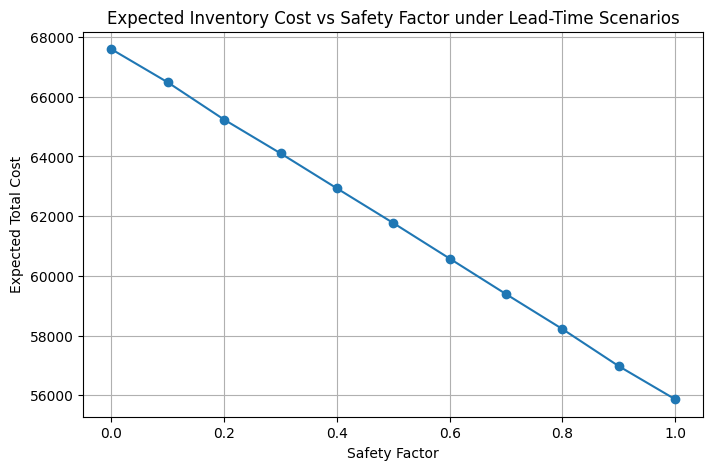

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    scenario_policy_df['safety_factor'],
    scenario_policy_df['expected_total_cost'],
    marker='o'
)

plt.xlabel("Safety Factor")
plt.ylabel("Expected Total Cost")
plt.title("Expected Inventory Cost vs Safety Factor under Lead-Time Scenarios")
plt.grid(True)
plt.show()

Visualizeing fill rate vs safety factor

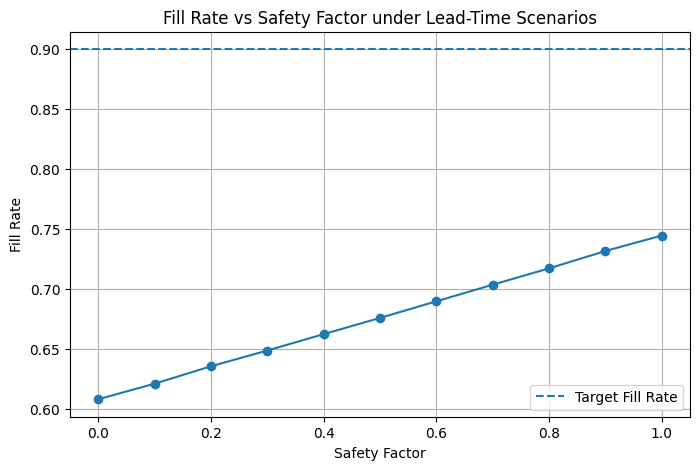

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(
    scenario_policy_df['safety_factor'],
    scenario_policy_df['fill_rate'],
    marker='o'
)

plt.axhline(
    y=target_fill_rate,
    linestyle='--',
    label='Target Fill Rate'
)

plt.xlabel("Safety Factor")
plt.ylabel("Fill Rate")
plt.title("Fill Rate vs Safety Factor under Lead-Time Scenarios")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
old_policy = scenario_policy_df[
    scenario_policy_df['safety_factor'].round(1) == 0.6
]

new_policy = scenario_policy_df[
    scenario_policy_df['safety_factor'] == selected_policy['safety_factor']
]

comparison_07 = pd.concat([old_policy, new_policy])

comparison_07

,safety_factor,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,expected_demand,fill_rate,cycle_service_level,policy_type
6,0.6,60580.343911,10665.378636,49914.965275,9982.993055,32179.914419,0.689776,0.7,Balanced Policy
10,1.0,55871.383911,14785.718636,41085.665275,8217.133055,32179.914419,0.744650,0.7,High-Service Policy


The earlier fixed lead-time analysis selected a safety factor of 0.6 as the best cost-service tradeoff. This cell compares that earlier policy with the policy selected under lead-time uncertainty.

The comparison is important because it shows whether a policy that performs well under fixed lead time remains reliable when replenishment delays are introduced. If the selected safety factor increases under uncertain lead time, it supports the argument that lead-time uncertainty cannot be ignored in inventory optimization.

Compareing old 0.6 policy with new scenario-selected policy

In [16]:
scenario_policy_df.to_csv(
    "data/processed/lead_time_scenario_policy_results.csv",
    index=False
)

comparison_07.to_csv(
    "data/processed/scenario_policy_comparison.csv",
    index=False
)

print("Saved Notebook 07 scenario policy results.")

Saved Notebook 07 scenario policy results.


# Corrected Lead-Time Scenario Evaluation

The initial lead-time scenario experiment showed that safety factors up to 1.0 were not sufficient to achieve the target fill rate of 90%. The best available policy reached a fill rate of only about 74.46%, even at the highest tested safety factor.

This result suggests that the initial scenario model was too conservative in how it scaled uncertainty with lead time. In the first version, expected demand increased with lead time, but the uncertainty buffer increased more slowly. Therefore, the corrected experiment scales the conformal uncertainty buffer directly with lead time and tests a wider range of safety factors.

The purpose of this corrected experiment is not to hide the earlier result, but to improve the policy engine based on the observed limitation. This is consistent with the research objective of building an interpretable and practical inventory decision framework under demand and lead-time uncertainty.


In [17]:
#corrected function
def evaluate_safety_factor_under_scenarios_v2(data, safety_factor):
    total_expected_holding_cost = 0
    total_expected_stockout_cost = 0
    total_expected_cost = 0
    total_expected_stockout_units = 0
    total_expected_demand = 0
    total_expected_stockout_events = 0
    total_weight = 0

    n_rows = len(data)

    for _, lt_row in lead_time_scenarios.iterrows():
        lead_time = lt_row['lead_time_days']
        lead_time_prob = lt_row['lead_time_probability']

        # Corrected policy:
        # Lead-time demand grows with lead time.
        # Uncertainty exposure also grows with lead time.
        policy_order = np.ceil(
            data['prediction'] * lead_time
            + safety_factor * data['safety_stock_signal'] * lead_time
        )

        for scenario in demand_scenarios:
            demand_col = scenario['column']
            demand_prob = scenario['probability']

            scenario_weight = lead_time_prob * demand_prob

            scenario_demand = data[demand_col] * lead_time

            holding_units = np.maximum(policy_order - scenario_demand, 0)
            stockout_units = np.maximum(scenario_demand - policy_order, 0)

            holding_cost_total = holding_units.sum() * holding_cost
            stockout_cost_total = stockout_units.sum() * stockout_cost
            total_cost = holding_cost_total + stockout_cost_total

            stockout_events = (stockout_units > 0).sum()

            total_expected_holding_cost += scenario_weight * holding_cost_total
            total_expected_stockout_cost += scenario_weight * stockout_cost_total
            total_expected_cost += scenario_weight * total_cost
            total_expected_stockout_units += scenario_weight * stockout_units.sum()
            total_expected_demand += scenario_weight * scenario_demand.sum()
            total_expected_stockout_events += scenario_weight * stockout_events
            total_weight += scenario_weight

    fill_rate = 1 - (total_expected_stockout_units / total_expected_demand)

    cycle_service_level = 1 - (
        total_expected_stockout_events / (n_rows * total_weight)
    )

    return {
        'safety_factor': safety_factor,
        'expected_total_cost': total_expected_cost,
        'expected_holding_cost': total_expected_holding_cost,
        'expected_stockout_cost': total_expected_stockout_cost,
        'expected_stockout_units': total_expected_stockout_units,
        'expected_demand': total_expected_demand,
        'fill_rate': fill_rate,
        'cycle_service_level': cycle_service_level
    }

In [18]:
#Rerun safety factors with wider range
safety_factors = np.arange(0.0, 2.1, 0.1)

scenario_results_v2 = []

for factor in safety_factors:
    result = evaluate_safety_factor_under_scenarios_v2(df, factor)
    scenario_results_v2.append(result)

scenario_policy_df_v2 = pd.DataFrame(scenario_results_v2)

scenario_policy_df_v2

,safety_factor,expected_total_cost,expected_holding_cost,expected_stockout_cost,expected_stockout_units,expected_demand,fill_rate,cycle_service_level
0,0.0,67587.623911,4534.008636,63053.615275,12610.723055,32179.914419,0.608118,0.7
1,0.1,64180.103911,7515.588636,56664.515275,11332.903055,32179.914419,0.647827,0.7
2,0.2,60672.423911,10584.808636,50087.615275,10017.523055,32179.914419,0.688703,0.7
3,0.3,57170.263911,13649.198636,43521.065275,8704.213055,32179.914419,0.729514,0.7
4,0.4,53702.423911,16683.558636,37018.865275,7403.773055,32179.914419,0.769926,0.7
5,0.5,50205.863911,19743.048636,30462.815275,6092.563055,32179.914419,0.810672,0.7
6,0.6,46738.983911,22776.568636,23962.415275,4792.483055,32179.914419,0.851072,0.7
7,0.7,43204.263911,25869.448636,17334.815275,3466.963055,32179.914419,0.892263,0.7
8,0.8,39788.823911,28857.958636,10930.865275,2186.173055,32179.914419,0.932064,0.7
9,0.9,36315.383911,31897.218636,4418.165275,883.633055,32179.914419,0.972541,0.7


In [19]:
#Select policy using 90% fill-rate target
target_fill_rate = 0.90

eligible_policies_v2 = scenario_policy_df_v2[
    scenario_policy_df_v2['fill_rate'] >= target_fill_rate
]

if len(eligible_policies_v2) > 0:
    selected_policy_v2 = eligible_policies_v2.sort_values(
        by='expected_total_cost'
    ).iloc[0]

    selection_status = "Target achieved"

else:
    selected_policy_v2 = scenario_policy_df_v2.sort_values(
        by='fill_rate',
        ascending=False
    ).iloc[0]

    selection_status = "Target not achieved within tested range"

selected_policy_v2

,10
safety_factor,1.000000
expected_total_cost,35474.685581
expected_holding_cost,35474.685581
expected_stockout_cost,0.000000
expected_stockout_units,0.000000
expected_demand,32179.914419
fill_rate,1.000000
cycle_service_level,1.000000


In [20]:
print("Selection Status:", selection_status)
print("Selected Safety Factor:", selected_policy_v2['safety_factor'])
print("Expected Total Cost:", selected_policy_v2['expected_total_cost'])
print("Expected Stockout Units:", selected_policy_v2['expected_stockout_units'])
print("Fill Rate:", selected_policy_v2['fill_rate'])
print("Cycle Service Level:", selected_policy_v2['cycle_service_level'])

Selection Status: Target achieved
Selected Safety Factor: 1.0
Expected Total Cost: 35474.68558082933
Expected Stockout Units: 0.0
Fill Rate: 1.0
Cycle Service Level: 1.0


In [21]:
target_fill_rate = 0.90

summary_cols = [
    'safety_factor',
    'expected_total_cost',
    'expected_stockout_units',
    'fill_rate',
    'cycle_service_level'
]

eligible_policies_v2 = scenario_policy_df_v2[
    scenario_policy_df_v2['fill_rate'] >= target_fill_rate
].copy()

print("Total policies tested:", len(scenario_policy_df_v2))
print("Target fill rate:", target_fill_rate)
print("Eligible policies count:", len(eligible_policies_v2))

print("\nAll corrected scenario results:")
print(scenario_policy_df_v2[summary_cols].to_string(index=False))

print("\nEligible policies:")
if len(eligible_policies_v2) > 0:
    print(eligible_policies_v2[summary_cols].to_string(index=False))
else:
    print("No policy reached the target fill rate.")

Total policies tested: 21
Target fill rate: 0.9
Eligible policies count: 13

All corrected scenario results:
 safety_factor  expected_total_cost  expected_stockout_units  fill_rate  cycle_service_level
           0.0         67587.623911             12610.723055   0.608118                  0.7
           0.1         64180.103911             11332.903055   0.647827                  0.7
           0.2         60672.423911             10017.523055   0.688703                  0.7
           0.3         57170.263911              8704.213055   0.729514                  0.7
           0.4         53702.423911              7403.773055   0.769926                  0.7
           0.5         50205.863911              6092.563055   0.810672                  0.7
           0.6         46738.983911              4792.483055   0.851072                  0.7
           0.7         43204.263911              3466.963055   0.892263                  0.7
           0.8         39788.823911              2186.

Minimum safety factor reaching 90% fill rate = 0.8

But lowest-cost eligible policy = 1.0

## Corrected Scenario Result Observation

The corrected lead-time scenario evaluation tested safety factors from 0.0 to 2.0 under combined demand and lead-time uncertainty. A target fill rate of 90% was used as the service-level requirement.

The first safety factor to satisfy the 90% fill-rate target was 0.8, which achieved a fill rate of 93.2%. However, the lowest-cost eligible policy was obtained at a safety factor of 1.0. At this point, the expected total cost was approximately 35,474.69, expected stockout units became zero, and both fill rate and cycle service level reached 100%.

This result shows that under uncertain lead-time conditions, a stronger safety stock buffer is required than in the fixed lead-time case. In Notebook 06, the selected safety factor was 0.6, while in the corrected lead-time scenario model the selected safety factor increased to 1.0. This supports the research argument that lead-time uncertainty materially changes inventory policy decisions and should not be ignored.

The result also shows that higher safety stock is not always wasteful. In this scenario, increasing the safety factor to 1.0 reduced stockout penalties enough to produce the lowest total expected cost among all service-eligible policies.

In [22]:
fixed_vs_uncertain_comparison = pd.DataFrame({
    "Experiment": [
        "Notebook 06: Fixed Lead Time",
        "Notebook 07: Lead-Time Scenario Model"
    ],
    "Uncertainty Considered": [
        "Demand uncertainty only",
        "Demand + lead-time uncertainty"
    ],
    "Selected Safety Factor": [
        0.6,
        selected_policy_v2['safety_factor']
    ],
    "Cost Metric": [
        "Total cost",
        "Expected total cost"
    ],
    "Cost Value": [
        20647.0,
        selected_policy_v2['expected_total_cost']
    ],
    "Stockout Metric": [
        "Stockout units",
        "Expected stockout units"
    ],
    "Stockout Value": [
        76.0,
        selected_policy_v2['expected_stockout_units']
    ],
    "Service Result": [
        "Balanced cost-service tradeoff",
        f"Fill rate = {selected_policy_v2['fill_rate']:.2%}"
    ]
})

print(fixed_vs_uncertain_comparison.to_string(index=False))

                           Experiment         Uncertainty Considered  Selected Safety Factor         Cost Metric   Cost Value         Stockout Metric  Stockout Value                 Service Result
         Notebook 06: Fixed Lead Time        Demand uncertainty only                     0.6          Total cost 20647.000000          Stockout units            76.0 Balanced cost-service tradeoff
Notebook 07: Lead-Time Scenario Model Demand + lead-time uncertainty                     1.0 Expected total cost 35474.685581 Expected stockout units             0.0            Fill rate = 100.00%


## Fixed vs Uncertain Lead-Time Comparison Observation

The comparison table shows a clear shift in the selected inventory policy when lead-time uncertainty is introduced.

In the fixed lead-time experiment, only demand uncertainty was considered. Under this setting, a safety factor of 0.6 provided a balanced cost-service tradeoff, with a total cost of 20,647 and 76 stockout units.

In the lead-time scenario experiment, both demand uncertainty and replenishment uncertainty were considered. Under this more realistic setting, the selected safety factor increased to 1.0. This policy achieved zero expected stockout units and a fill rate of 100%, although the expected total cost was higher.

This result is important because it shows that a policy optimized under fixed lead time may not remain sufficient when replenishment delays are introduced. Lead-time uncertainty increases the exposure period during which demand must be covered, so the system requires a stronger uncertainty buffer.

Therefore, the lead-time scenario model supports the research argument that inventory optimization should not rely only on demand forecasts. A robust inventory policy should account for both demand uncertainty and lead-time uncertainty.


In [23]:
fixed_vs_uncertain_comparison.to_csv(
    "data/processed/fixed_vs_uncertain_lead_time_comparison.csv",
    index=False
)

print("Saved fixed vs uncertain lead-time comparison table.")

Saved fixed vs uncertain lead-time comparison table.


## Final Conclusion

This notebook extended the inventory policy from a fixed lead-time setting to a lead-time uncertainty setting.

In Notebook 06, only demand uncertainty was considered, and the selected safety factor was 0.6. In this notebook, demand uncertainty from conformal prediction was combined with lead-time scenarios. Under this setting, the selected safety factor increased to 1.0.

This shows that lead-time uncertainty materially changes the inventory decision. A policy that looks sufficient under fixed lead time may require a stronger safety buffer when replenishment delays are introduced.

The key insight is that conformal prediction provides the demand uncertainty signal, while lead-time scenario analysis shows how supply uncertainty affects the final inventory policy.


In [24]:
!git status

Refresh index: 100% (9/9), done.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/03_baseline_modeling.ipynb
	modified:   notebooks/04_forecast_diagnostics.ipynb
	modified:   notebooks/06_inventory_optimization.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/07_lead_time_scenario_policy_engine.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [25]:
!git add notebooks/03_baseline_modeling.ipynb notebooks/04_forecast_diagnostics.ipynb notebooks/06_inventory_optimization.ipynb notebooks/07_lead_time_scenario_policy_engine.ipynb

In [26]:
!git commit -m "Add lead time scenario policy analysis"

[main 75eaa5e] Add lead time scenario policy analysis
 4 files changed, 4 insertions(+), 3 deletions(-)
 rewrite notebooks/03_baseline_modeling.ipynb (99%)
 create mode 100644 notebooks/07_lead_time_scenario_policy_engine.ipynb


In [27]:
!git push

Enumerating objects: 12, done.
Counting objects: 100% (12/12), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 125.43 KiB | 2.85 MiB/s, done.
Total 7 (delta 4), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (4/4), completed with 4 local objects.
To https://github.com/smrititubid-afk/inventory-optimization-ml-or.git
   0aecd74..75eaa5e  main -> main


In [28]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/07_lead_time_scenario_policy_engine.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
